# Libraries

In [7]:
from pathlib import Path
from joblib import Parallel, delayed
from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sn

import scipy as sp
import numpy as np
import pandas as pd

import neurokit2 as nk

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import *
from sklearn.inspection import permutation_importance

import xgboost
import shap
from boruta import BorutaPy

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from torchview import draw_graph
import optuna

import wfdb
from helper_code import *

## Settings

In [6]:
%load_ext autoreload

%autoreload 2

# Control figure size
%matplotlib inline
figsize=(14, 4)

# Random seed
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Detection of Chagas Disease from the ECG: PhysioNet Challenge 2025

## Introduction

Chagas disease is a potentially life-threatening illness caused by the protozoan parasite Trypanosoma cruzi (T. cruzi). It is found mainly in endemic areas of 21 countries in Latin America, where it is mostly transmitted to humans by the feces of triatomine bugs known as "kissing bugs". The disease is also known as American trypanosomiasis.

The disease is named after the Brazilian physician Carlos Chagas, who discovered it in 1909. The disease can be acute or chronic, but the chronic form is the most common and usually develops 10 to 30 years after the initial infection. The acute phase of the disease is usually mild or asymptomatic, but the chronic phase can cause serious heart and digestive problems.

The disease is diagnosed by detecting the parasite in the blood or by serological tests. The electrocardiogram (ECG) is an important tool for diagnosing Chagas disease, as it can show changes in the heart's electrical activity that are characteristic of the disease.

The goal of this challenge is to develop algorithms that can automatically detect Chagas disease from ECG signals. The challenge is based on a dataset of ECG signals from patients with Chagas disease and healthy controls. The dataset is provided by the PhysioNet Challenge 2025.

In [4]:
train_data_folder = Path("code15_wfdb")

train_records = find_records(train_data_folder.absolute().__str__())

We can also get the record of a patient combined with the demographic information and plot the ECG signal.

In [5]:
def get_patient_data(record_id: int) -> tuple[str, int, bool, np.ndarray, float]:
    record = f"{str(train_data_folder.absolute())}{os.sep}{record_id}"
    header = load_header(record)
    signals, fields = load_signals(record)
    frequency = get_sampling_frequency(header)
    label = get_label(header)

    return record, record_id, label, signals, frequency

In [6]:
record, exam_id, label, signals, frequency = get_patient_data(record_id=train_records[1])
print(f"Record file: {record}\nExam ID: {exam_id}\nLabel: {label}")

Record file: d:\Coding\GitHub\ECG-Chagas\code15_wfdb\1000078
Exam ID: 1000078
Label: 0


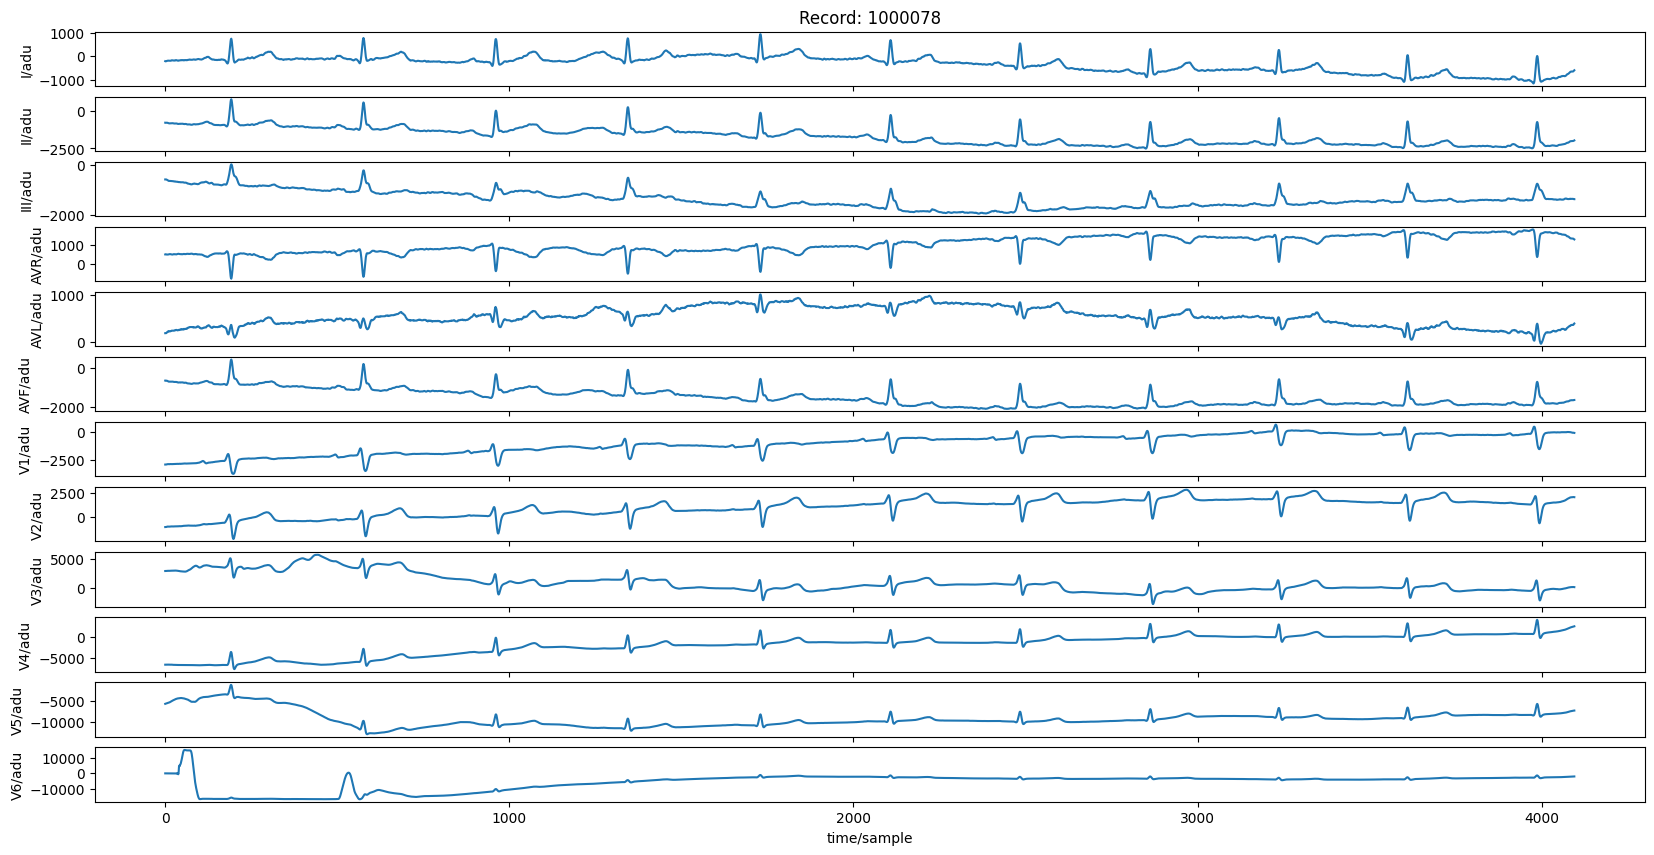

In [7]:
wfdb.plot_wfdb(record=wfdb.rdrecord(record, physical=False), figsize=(20, 10), time_units='samples')

---

## Dataset

In [8]:
data_path = Path("data")
if not (data_path / "signals_features.csv").exists():
    !python preprocessing.py --exams code15_hdf5/exams.csv --labels code15_hdf5/code15_chagas_labels.csv --train code15_wfdb/ --output data/ --seed 42 --jobs -1

In [9]:
df = pd.read_csv(data_path / "signals_features.csv")

In [10]:
to_be_dropped = df[df['ST_slope_mean'].isna()].exam_id.values.tolist()

In [11]:
df = df[~df['exam_id'].isin(to_be_dropped)].fillna(value=0)

In [12]:
df.isna().sum()

exam_id                 0
P_wave_duration_mean    0
P_wave_duration_std     0
P_wave_duration_min     0
P_wave_duration_max     0
PR_interval_mean        0
PR_interval_std         0
PR_interval_min         0
PR_interval_max         0
PR_segment_mean         0
PR_segment_std          0
PR_segment_min          0
PR_segment_max          0
QRS_duration_mean       0
QRS_duration_std        0
QRS_duration_min        0
QRS_duration_max        0
QT_interval_mean        0
QT_interval_std         0
QT_interval_min         0
QT_interval_max         0
ST_segment_mean         0
ST_segment_std          0
ST_segment_min          0
ST_segment_max          0
ST_slope_mean           0
ST_slope_std            0
ST_slope_min            0
ST_slope_max            0
HRV_MeanNN              0
HRV_SDNN                0
HRV_RMSSD               0
HRV_SDSD                0
HRV_CVNN                0
HRV_CVSD                0
HRV_MedianNN            0
HRV_MadNN               0
HRV_MCVNN               0
HRV_IQRNN   

# EDA

In [13]:
df.drop('exam_id', axis=1, inplace=True)

In [14]:
df.head()

,P_wave_duration_mean,P_wave_duration_std,P_wave_duration_min,P_wave_duration_max,PR_interval_mean,PR_interval_std,PR_interval_min,PR_interval_max,PR_segment_mean,PR_segment_std,...,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,age,is_male,chagas
0,36.250000,10.856203,17.5,47.5,137.812500,39.830836,110.0,222.5,101.562500,40.903578,...,1110.0,55.555556,66.666667,865.0,1135.0,4.500000,250.0000,55,False,False
1,44.285714,4.498677,37.5,52.5,87.857143,0.944911,87.5,90.0,43.571429,4.531635,...,735.0,0.000000,12.500000,710.0,740.0,2.666667,0.0000,38,False,False
2,66.590909,5.156637,60.0,75.0,86.818182,8.069302,72.5,95.0,20.227273,10.808246,...,781.0,0.000000,8.333333,735.0,792.5,6.000000,23.4375,48,False,False
3,23.333333,7.180703,15.0,40.0,146.944444,16.619726,127.5,182.5,123.611111,17.682579,...,787.0,25.000000,66.666667,640.0,822.5,4.000000,148.4375,33,False,False
4,65.000000,25.248762,35.0,92.5,128.125000,68.446299,82.5,230.0,63.125000,62.861455,...,800.0,0.000000,16.666667,737.5,805.0,3.000000,46.8750,81,False,False


In [15]:
df.describe()

,P_wave_duration_mean,P_wave_duration_std,P_wave_duration_min,P_wave_duration_max,PR_interval_mean,PR_interval_std,PR_interval_min,PR_interval_max,PR_segment_mean,PR_segment_std,...,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,age
count,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,...,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000,13082.000000
mean,47.571864,11.256285,34.184949,62.930936,99.432490,19.692697,75.185943,123.768728,51.860626,23.102238,...,0.902968,831.088786,912.627924,18.611972,34.804152,789.424782,957.375019,3.539173,37.598776,56.727488
std,13.670629,9.219219,15.830392,19.815176,34.775412,22.206907,40.344265,48.835064,36.539766,22.136257,...,0.301998,176.975199,194.883049,26.396604,29.467831,194.143079,240.924969,1.737762,90.700664,17.936534
min,2.500000,0.000000,0.000000,2.500000,-133.750000,0.000000,-222.500000,-132.500000,-165.000000,0.000000,...,0.000000,302.500000,330.000000,0.000000,0.000000,157.500000,332.500000,1.000000,0.000000,17.000000
25%,39.375000,4.330127,20.000000,52.500000,80.000000,5.543389,60.000000,95.000000,29.000000,8.092962,...,0.695243,717.500000,787.500000,0.000000,0.000000,667.500000,812.500000,2.333333,0.000000,43.000000
50%,47.916667,8.720187,35.000000,60.000000,94.000000,12.990381,72.500000,112.500000,44.722222,17.227038,...,0.824285,832.000000,896.500000,0.000000,33.333333,797.500000,927.500000,3.000000,0.000000,58.000000
75%,55.833333,15.990276,45.000000,72.500000,111.250000,24.706612,92.500000,137.500000,65.714286,30.845296,...,1.012095,945.000000,1013.500000,33.333333,60.000000,915.000000,1057.500000,4.333333,31.250000,72.000000
max,206.250000,120.847700,137.500000,282.500000,650.000000,274.003878,650.000000,650.000000,542.500000,272.236111,...,3.119127,2050.000000,3182.500000,94.736842,94.736842,2040.000000,4752.500000,16.000000,937.500000,94.000000


In [16]:
df.chagas.value_counts(normalize=True)

chagas
True     0.500153
False    0.499847
Name: proportion, dtype: float64

Cast the boolean columns to integers.

In [17]:
df['is_male'] = df['is_male'].astype(int)
df['chagas'] = df['chagas'].astype(int)

Exctract the numerical and categorical columns.

In [18]:
num_cols = [c for c in df.columns[:-1] if df[c].nunique() > 2]
cat_cols = [c for c in df.columns[:-1] if df[c].nunique() == 2]
print(f'Numeric: {num_cols}\nTotal: {len(num_cols)}')
print(f'Categorical: {cat_cols}\nTotal: {len(cat_cols)}')

Numeric: ['P_wave_duration_mean', 'P_wave_duration_std', 'P_wave_duration_min', 'P_wave_duration_max', 'PR_interval_mean', 'PR_interval_std', 'PR_interval_min', 'PR_interval_max', 'PR_segment_mean', 'PR_segment_std', 'PR_segment_min', 'PR_segment_max', 'QRS_duration_mean', 'QRS_duration_std', 'QRS_duration_min', 'QRS_duration_max', 'QT_interval_mean', 'QT_interval_std', 'QT_interval_min', 'QT_interval_max', 'ST_segment_mean', 'ST_segment_std', 'ST_segment_min', 'ST_segment_max', 'ST_slope_mean', 'ST_slope_std', 'ST_slope_min', 'ST_slope_max', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'age']
Total: 48
Categorical: ['is_male']
Total: 1


Plot the distribution of the numerical columns.

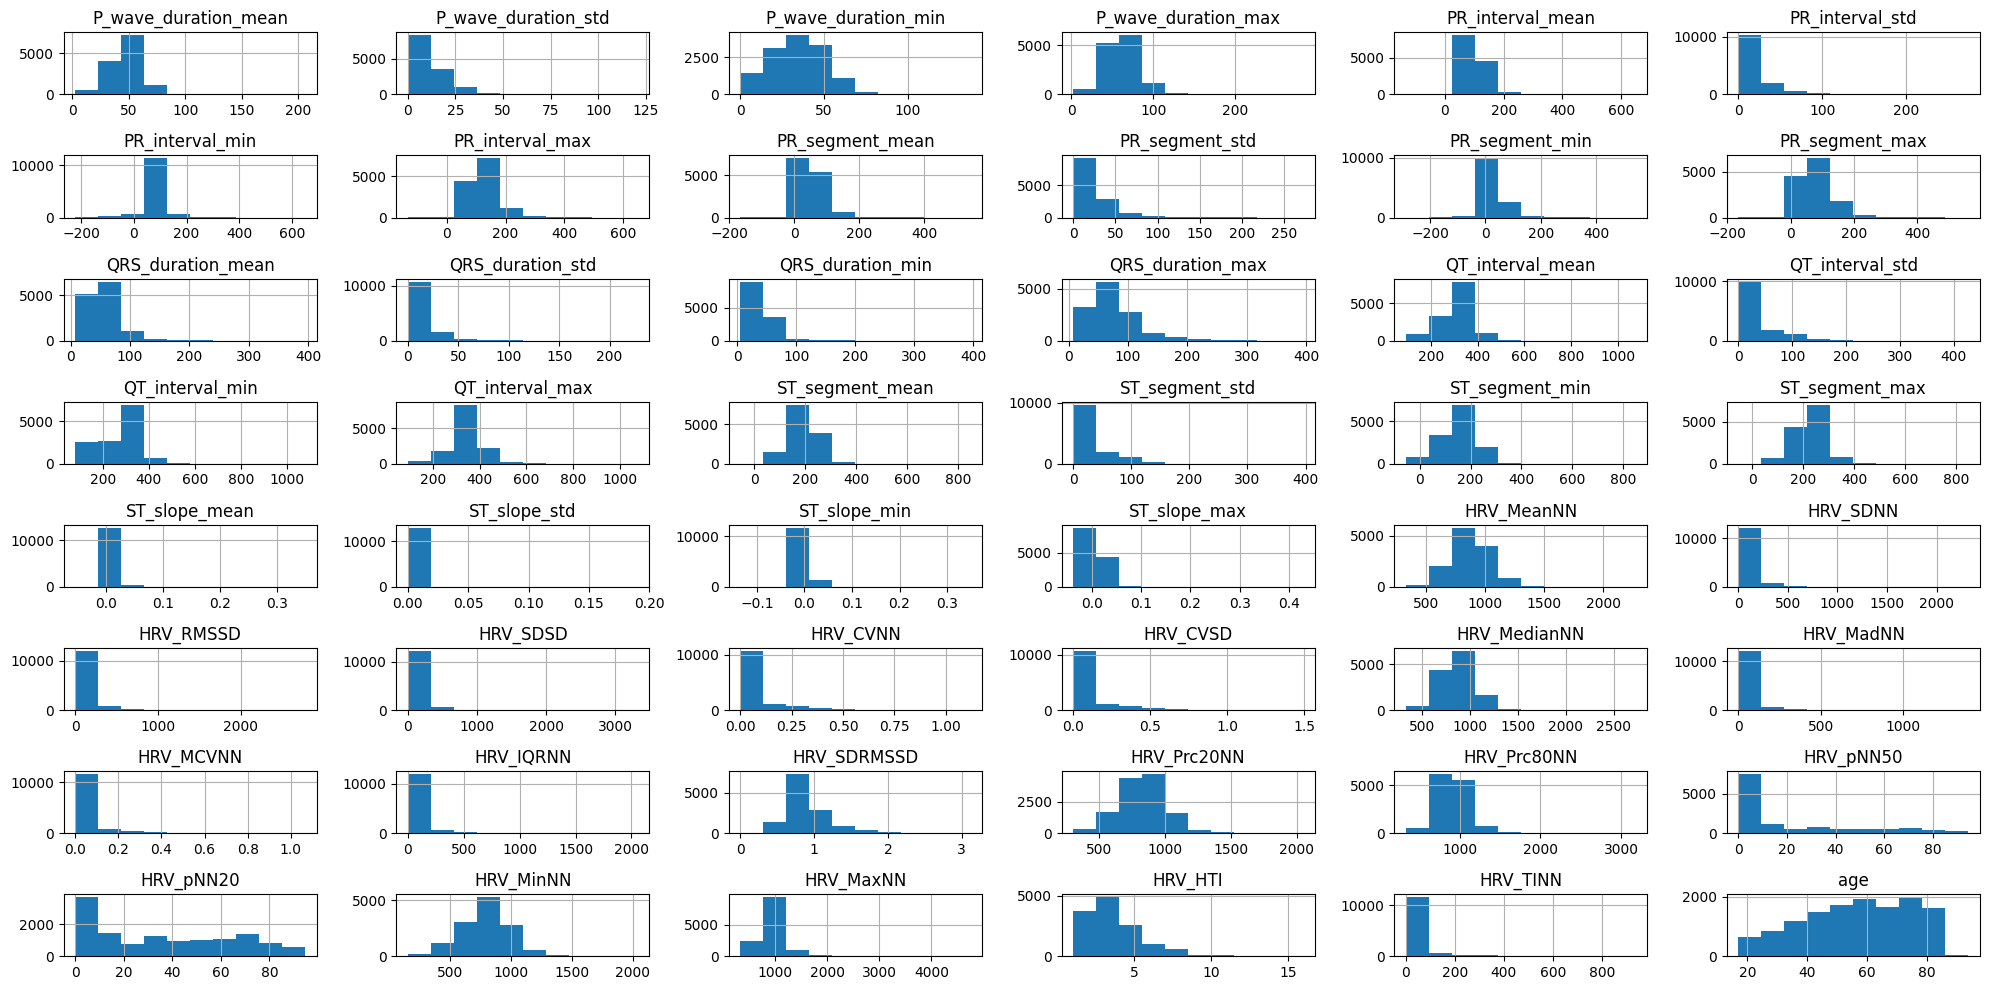

In [19]:
_, axes = plt.subplots(nrows=8, ncols=6, figsize=(20, 10))
for ax, cname in zip(axes.ravel(), num_cols):
    df.hist(cname, ax=ax)
plt.tight_layout()
plt.show()

Plot the distribution of the categorical columns.

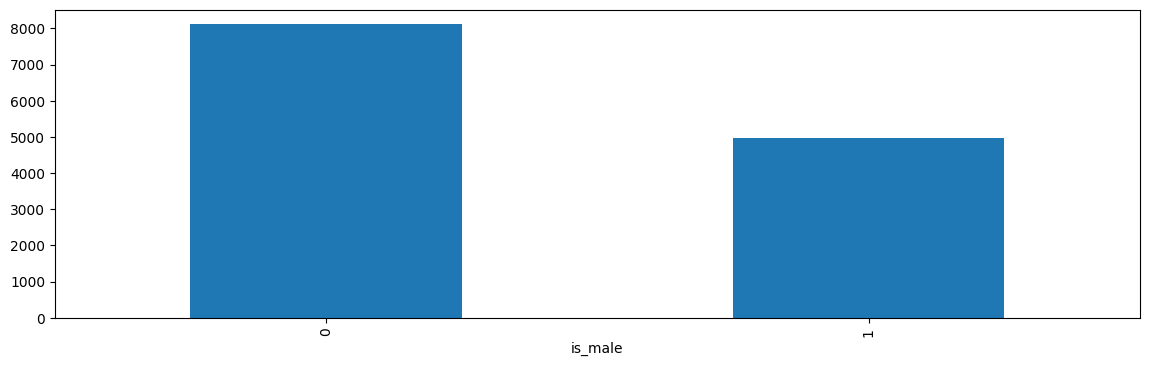

In [20]:
_, axes = plt.subplots(nrows=1, ncols=1, figsize=figsize)
for cname in cat_cols:
    df[cname].value_counts().plot(kind='bar', ax=axes)

Plot the distribution of the target variable.

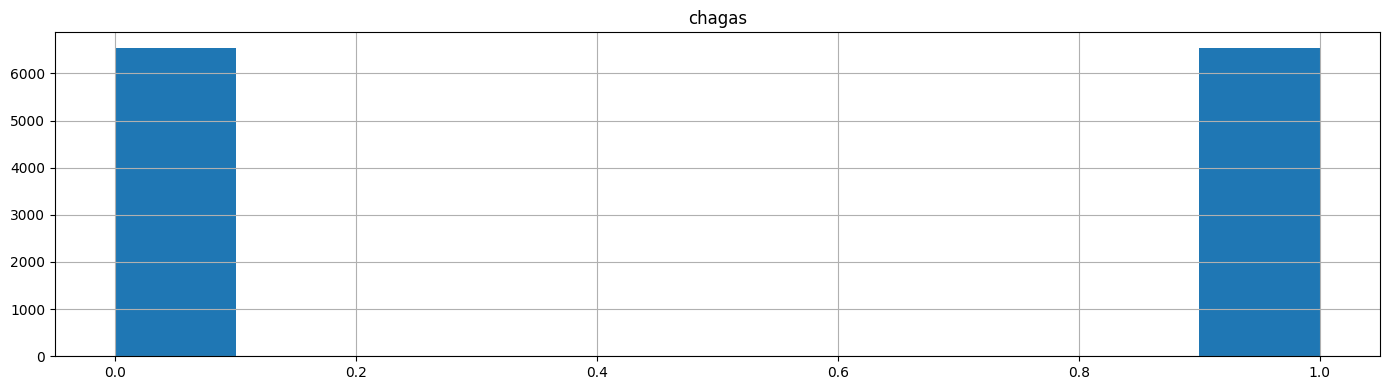

In [21]:
df.hist('chagas', figsize=figsize)
plt.tight_layout()

Plot the distribution of the target variable conditioned on the categorical columns.

In [22]:
df.groupby('is_male')['chagas'].mean()

is_male
0    0.512821
1    0.479477
Name: chagas, dtype: float64

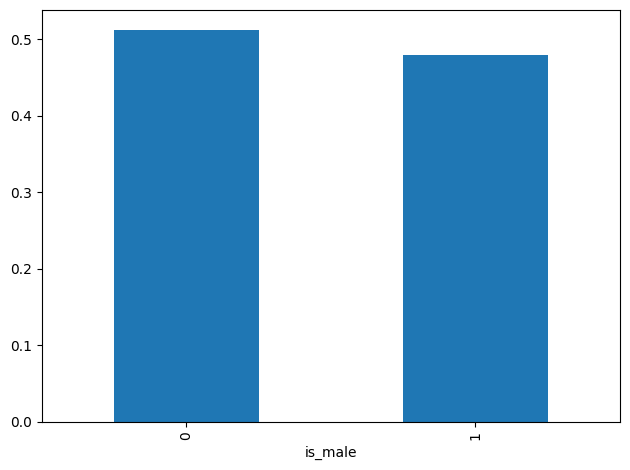

In [23]:
df.groupby('is_male')['chagas'].mean().plot.bar()
plt.tight_layout()

Plot the distribution of the numerical columns conditioned by the target variable.

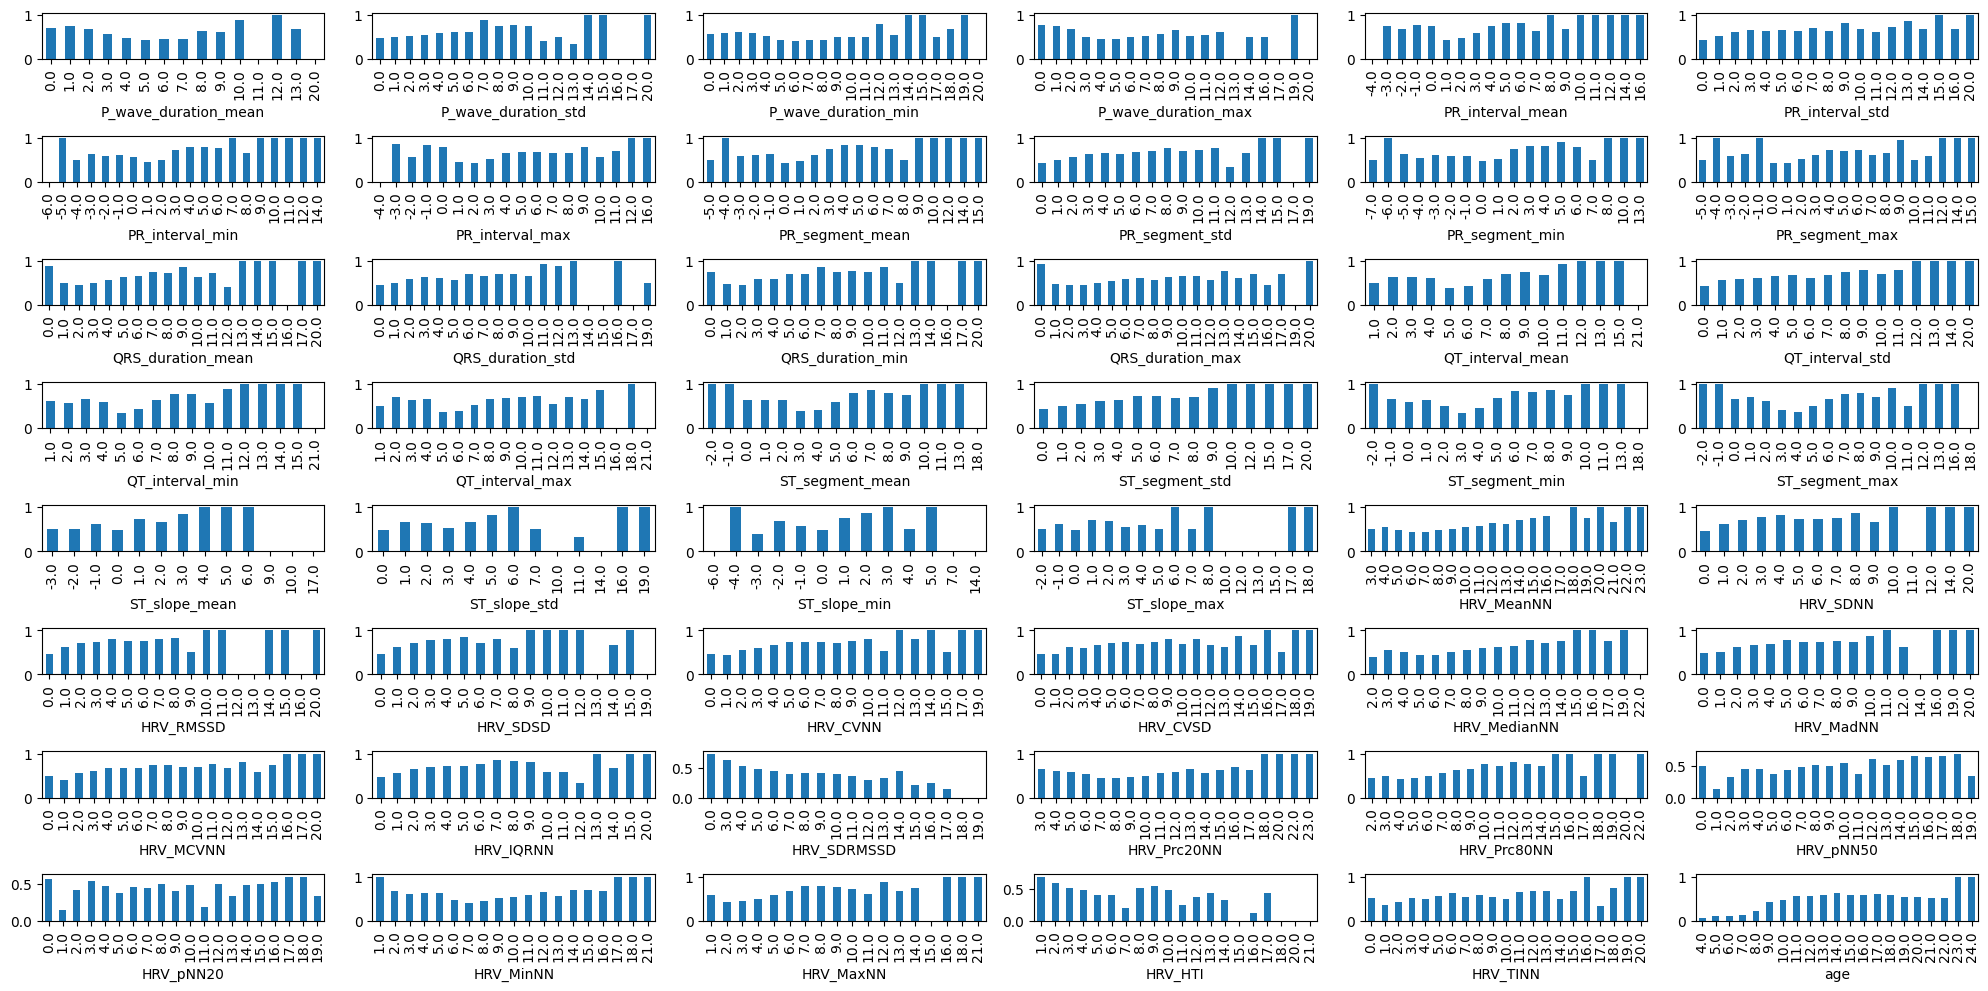

In [24]:
_, axes = plt.subplots(nrows=8, ncols=6, figsize=(20,10))
for ax, cname in zip(axes.ravel(), num_cols):
    bin_size = (df[cname].max() - df[cname].min()) / 20
    df['chagas'].groupby(df[cname] // bin_size).mean().plot.bar(ax=ax)
plt.tight_layout()

Plot the correlation matrix of the numerical columns.

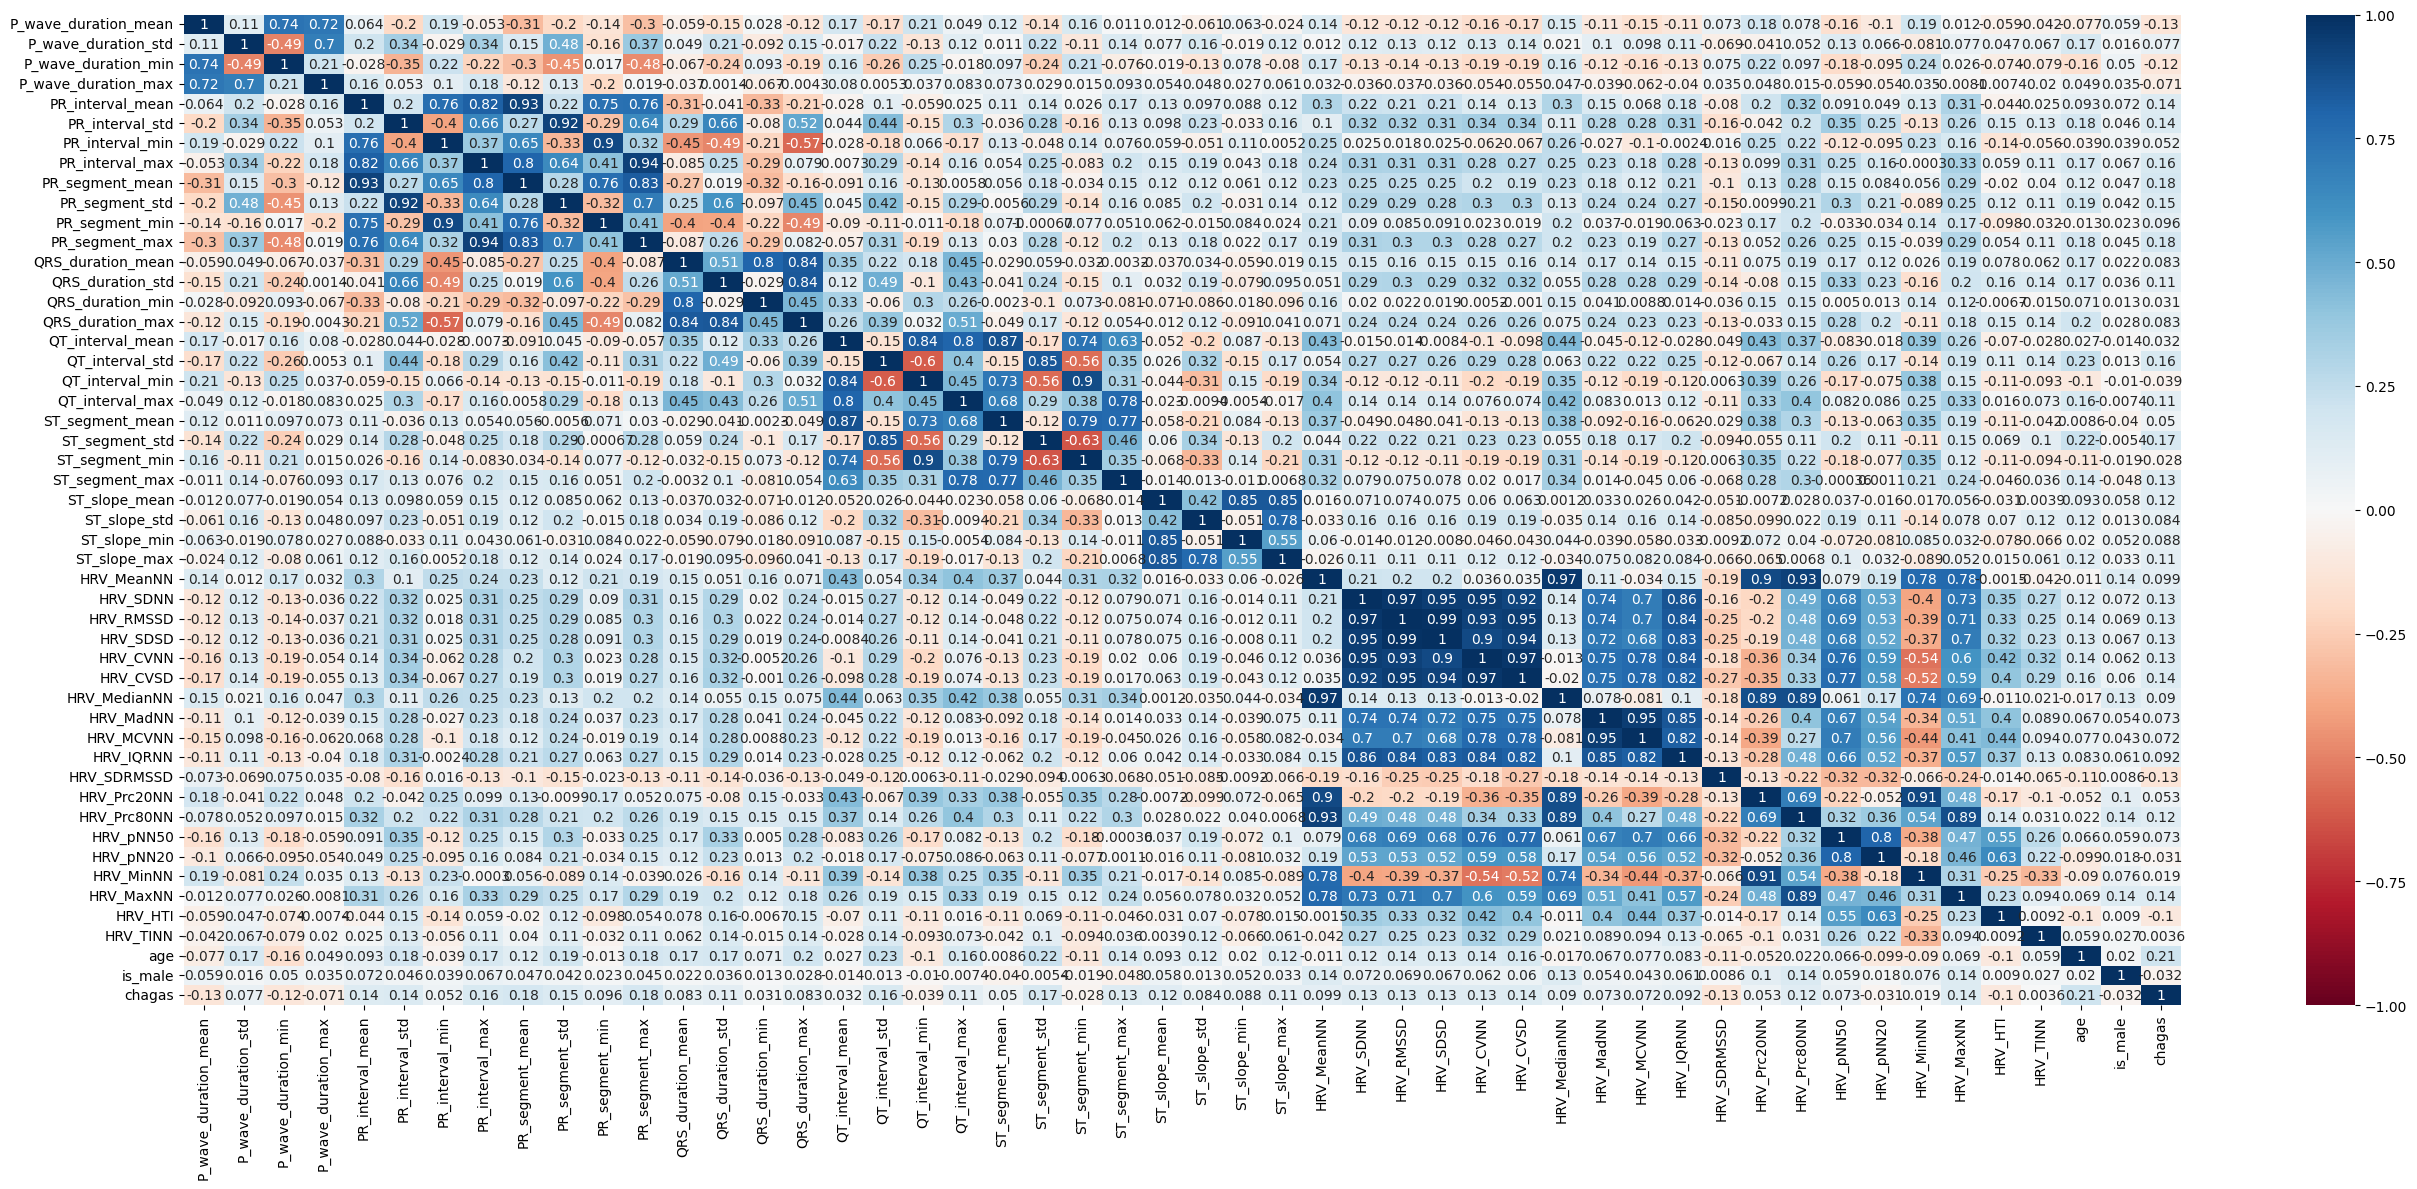

In [25]:
plt.figure(figsize=(27,12))
sn.heatmap(df.corr(method='pearson'), annot=True, vmin=-1, vmax=1, cmap='RdBu')
plt.tight_layout()

Split the data into training and testing sets. Shuffle the data and stratify the target variable.

Apply the StandardScaler to the numerical columns.

In [26]:
X, y = df.drop(columns='chagas', axis=1), df['chagas']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y, shuffle=True)
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Logistic Regression

In [26]:
base_est = LogisticRegression(penalty='l1', solver='saga',)
param_grid={'C': 1. / np.linspace(1e-1, 1e4, 100)}
gscv = GridSearchCV(base_est, param_grid=param_grid, scoring='roc_auc')
gscv.fit(X_train, y_train)
lr, lr_params = gscv.best_estimator_, gscv.best_params_

d:\Coding\GitHub\ECG-Chagas\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Coding\GitHub\ECG-Chagas\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Coding\GitHub\ECG-Chagas\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Coding\GitHub\ECG-Chagas\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Coding\GitHub\ECG-Chagas\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
d:\Coding\GitHub\ECG-Chagas\.venv\Lib\site-packages\sklearn\linea

In [27]:
lr_score_cv, lr_score_test = gscv.best_score_, roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
print(f'AUC score for C={lr_params["C"]:.2f}: {lr_score_cv:.2f} (cross-validation), {lr_score_test:.2f} (test)')

AUC score for C=10.00: 0.75 (cross-validation), 0.75 (test)


0.672720094749309
Confusion matrix:
[[0.35766144 0.1421475 ]
 [0.17462744 0.32556362]]


<Axes: >

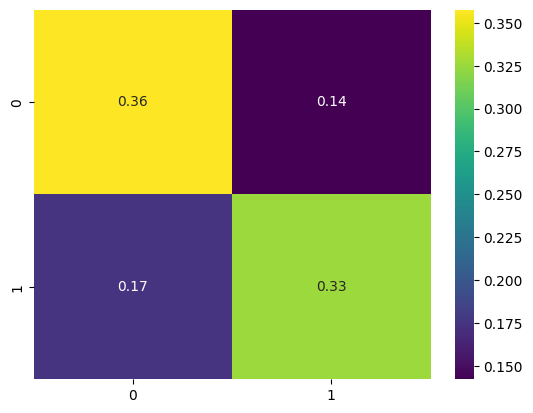

In [28]:
cm = confusion_matrix(y_test, lr.predict(X_test), labels=[0, 1], normalize='all')
print(f1_score(y_test, lr.predict(X_test)))
print(f'Confusion matrix:\n{cm}')
sn.heatmap(cm, annot=True, cmap='viridis')

In [29]:
pd.Series( lr.predict_proba(X_test)[:, 1]).describe()

count    2617.000000
mean        0.499486
std         0.206718
min         0.044349
25%         0.339359
50%         0.480320
75%         0.646140
max         0.997908
dtype: float64

<Axes: >

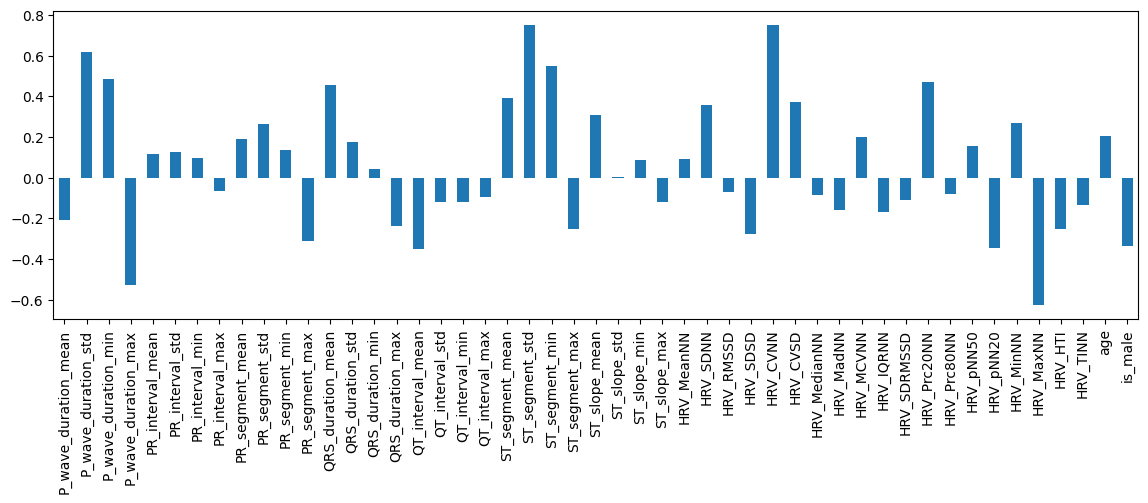

In [30]:
lr_coefs = pd.Series(index=X.columns, data=lr.coef_[0])
lr_coefs.plot(kind='bar', figsize=figsize)

# XGBoost

In [56]:
base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv = GridSearchCV(base_est, param_grid=param_grid)
gscv.fit(X_train, y_train)
xbm, xbm_params = gscv.best_estimator_, gscv.best_params_
y_pred = xbm.predict_proba(X_test)[:, 1]

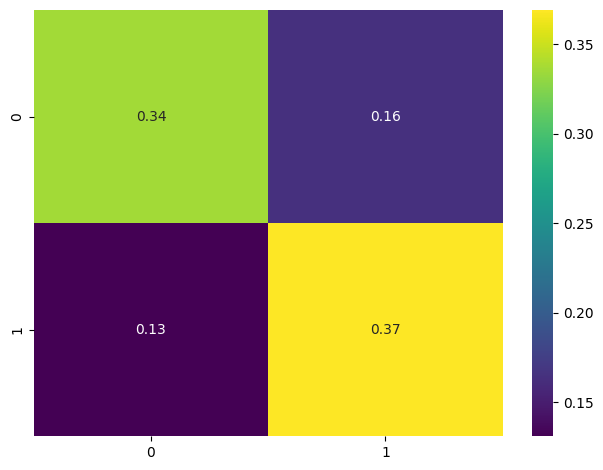

F1-score: 0.7144970414201183


In [57]:
y_pred_binary = xbm.predict(X_test)
cm = confusion_matrix(y_test, y_pred_binary, labels=[0, 1], normalize='all')
sn.heatmap(cm, annot=True, cmap='viridis')
plt.tight_layout()
plt.show()
print(f'F1-score: {f1_score(y_test, y_pred_binary)}')

In [38]:
#plt.figure(figsize=(20, 20))
#xgboost.plot_tree(xbm, ax=plt.gca(), num_trees=0)

In [59]:
xbm_score_test = roc_auc_score(y_test, y_pred)
print(f'AUC score for max_depth={xbm_params["max_depth"]}, n_estimators={xbm_params["n_estimators"]}, reg_lambda={xbm_params["reg_lambda"]:.2f}: {xbm_score_test:.2f} (test)')

AUC score for max_depth=4, n_estimators=40, reg_lambda=100.00: 0.78 (test)


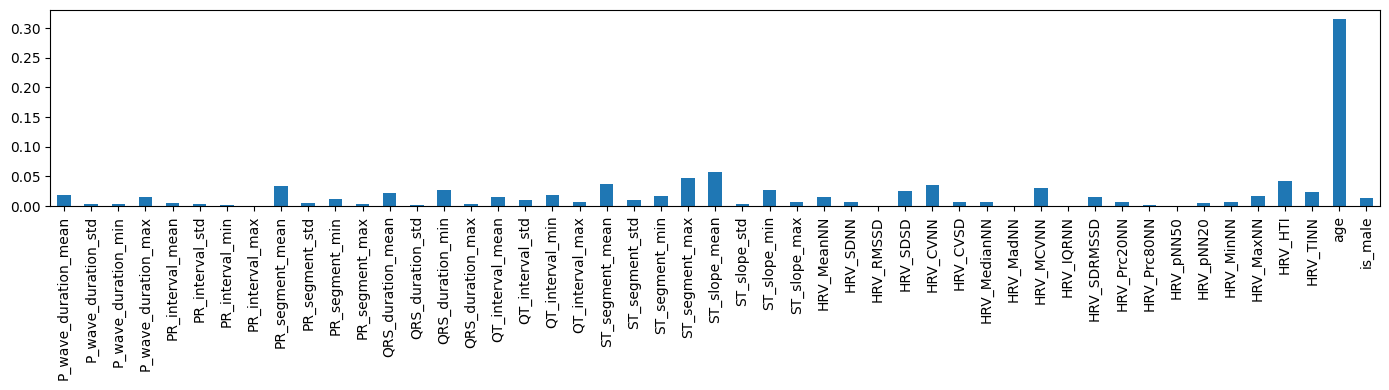

In [60]:
xbm_imp = pd.Series(index=X.columns, data=xbm.feature_importances_)
xbm_imp.plot(kind='bar', figsize=figsize)
plt.tight_layout()
plt.show()

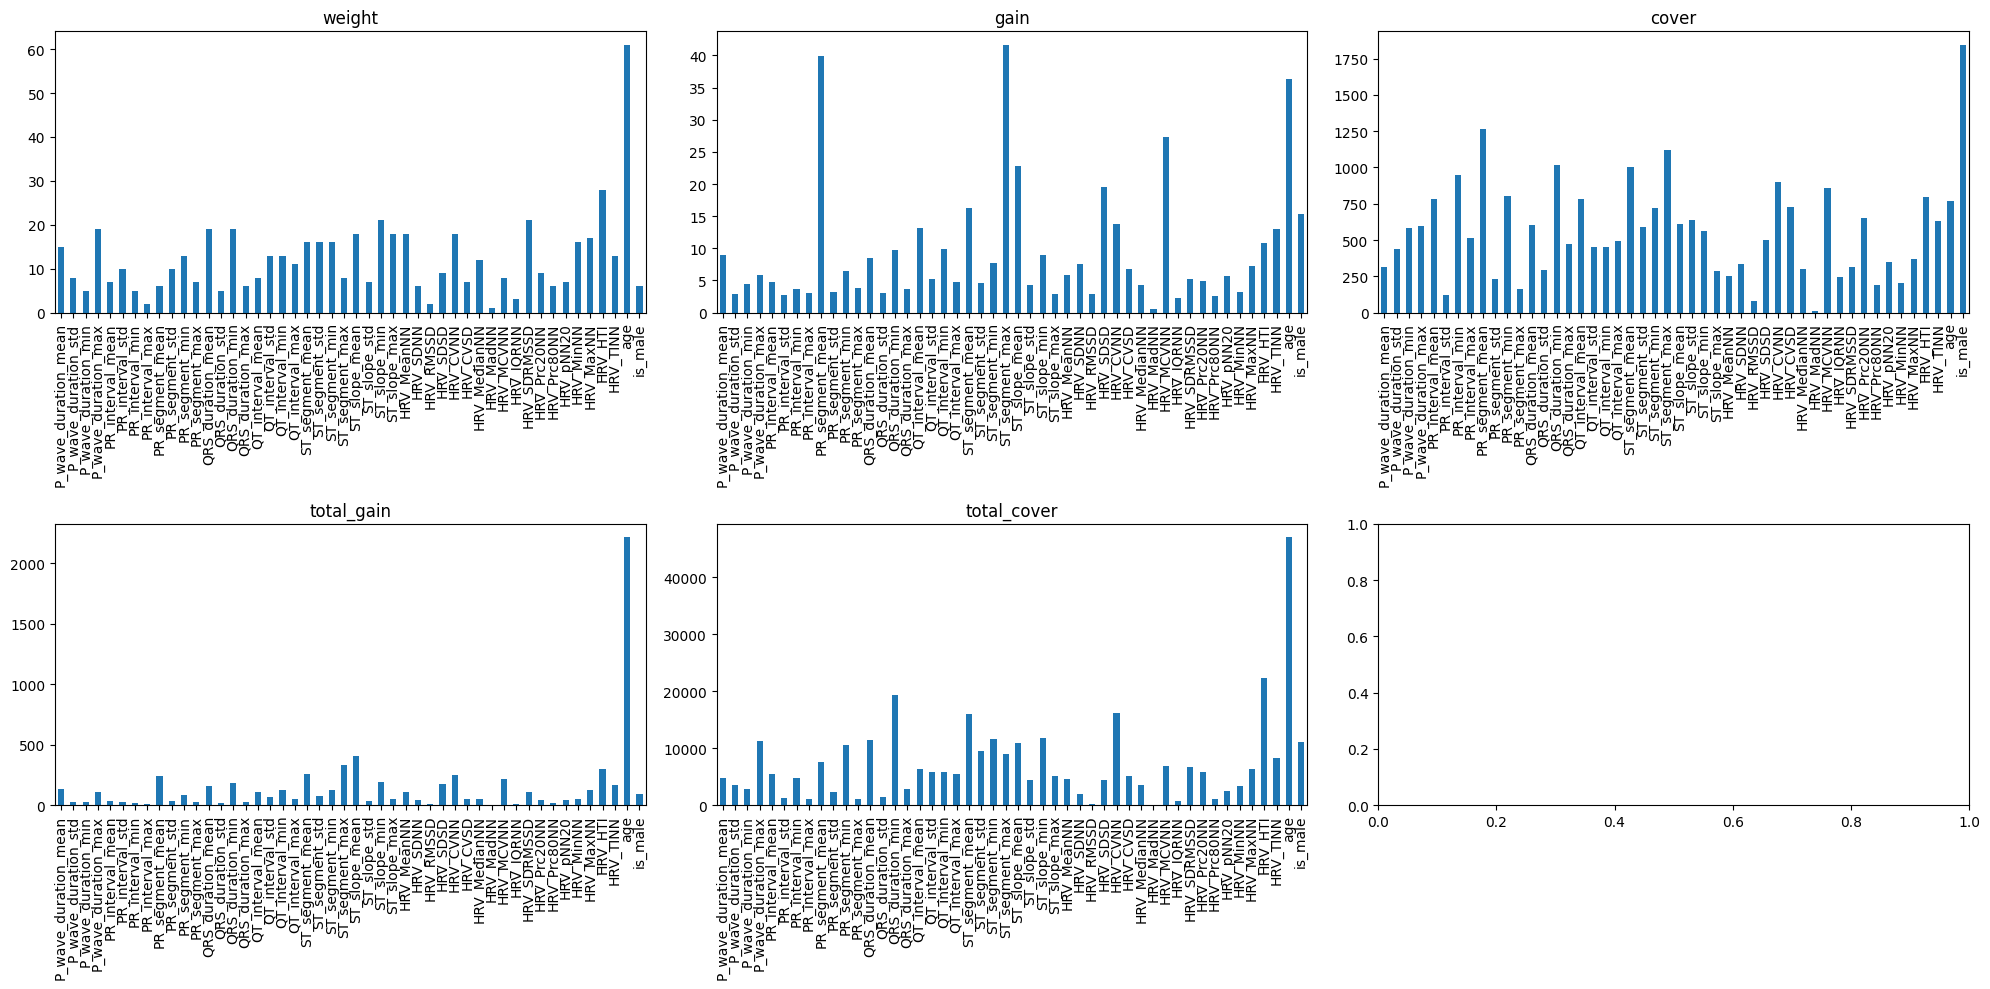

In [39]:
_, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
for ax, imp_type in zip(axes.ravel(), ['weight', 'gain', 'cover', 'total_gain', 'total_cover']):
    pd.Series(xbm.get_booster().get_score(importance_type=imp_type)).plot.bar(ax=ax, title=imp_type)
plt.tight_layout()

# SVC + Genetic Algorithm

We use the genetic algorithm to optimize the hyperparameters of the SVC.

In [26]:
from sklearn.svm import SVC
from geneticalgorithm import geneticalgorithm as ga
import numpy as np

def objective_function(params):
    C, gamma = params
    model = SVC(C=C, gamma=gamma, kernel='rbf')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    roc_auc = roc_auc_score(y_test, y_pred)
    print(f'C={C:.4f}, gamma={gamma:.4f}, AUC={roc_auc:.4f}')
    return -roc_auc 

We select the RBF kernel for the SVC, as it is the most common kernel for the SVC and is suitable for non-linearly separable data.

The two hyperparameters are the `C` parameter and the `gamma` parameter. 

`C` is the regularization parameter, which can be seen as the cost of misclassification. A large `C` penalizes misclassifications heavily, while a small `C` tolerates some misclassifications for simplicity. Thus, a large `C` can lead to overfitting, while a small `C` can lead to underfitting.

`gamma` is the kernel coefficient for the RBF kernel. A large `gamma` makes the decision boundary more complex, while a small `gamma` makes the decision boundary simpler. Thus, a large `gamma` can lead to overfitting, while a small `gamma` can lead to underfitting.

We now define a default range for the hyperparameters and the genetic algorithm.

In [27]:
varbound = np.array([[0.1, 1000],  # C range
                     [0.0001, 1]])  # gamma range

In order to have a good genetic pool, we set a substantial population size of 50 individuals, running for 10 generation and with a mutation probability of 0.3, which is quite high, but necessary to avoid local minima.

In [28]:
algorithm_params = {
    'max_num_iteration': 10,
    'population_size': 50,
    'mutation_probability': 0.3,
    'elit_ratio': 0.2,
    'crossover_probability': 0.5,
    'parents_portion': 0.3,
    'crossover_type': 'uniform',
    'max_iteration_without_improv': None
}

model = ga(
    function=objective_function,
    dimension=2,
    variable_type='real',
    variable_boundaries=varbound,
    algorithm_parameters=algorithm_params,
    progress_bar=True,
    function_timeout=1000
)

We now define the seeds for reproducibility and then run the genetic algorithm.

C=374.6027, gamma=0.9507, AUC=0.6121
C=779.7130, gamma=0.5969, AUC=0.6296
C=156.0789, gamma=0.0582, AUC=0.6595
C=333.7752, gamma=0.1430, AUC=0.6717
C=20.6824, gamma=0.9699, AUC=0.6113
C=938.5589, gamma=0.0009, AUC=0.7138
C=183.4862, gamma=0.3043, AUC=0.6591
C=7.1656, gamma=0.0232, AUC=0.6939
C=611.8917, gamma=0.1396, AUC=0.6702
C=973.7581, gamma=0.2328, AUC=0.6641
C=785.1974, gamma=0.1998, AUC=0.6694
C=983.2326, gamma=0.4668, AUC=0.6438
C=607.5841, gamma=0.1706, AUC=0.6683
C=13.3636, gamma=0.9422, AUC=0.6121
C=808.4165, gamma=0.3047, AUC=0.6591
C=230.9707, gamma=0.2411, AUC=0.6629
C=122.1260, gamma=0.4952, AUC=0.6404
C=173.4473, gamma=0.3911, AUC=0.6469
C=662.5560, gamma=0.3118, AUC=0.6553
C=208.0209, gamma=0.5677, AUC=0.6327
C=969.5877, gamma=0.7752, AUC=0.6216
C=395.2107, gamma=0.9267, AUC=0.6128
C=921.8820, gamma=0.0886, AUC=0.6610
C=520.8822, gamma=0.9612, AUC=0.6117
C=388.7384, gamma=0.2714, AUC=0.6606
C=586.7925, gamma=0.9653, AUC=0.6117
C=542.7418, gamma=0.1410, AUC=0.6713
C=165

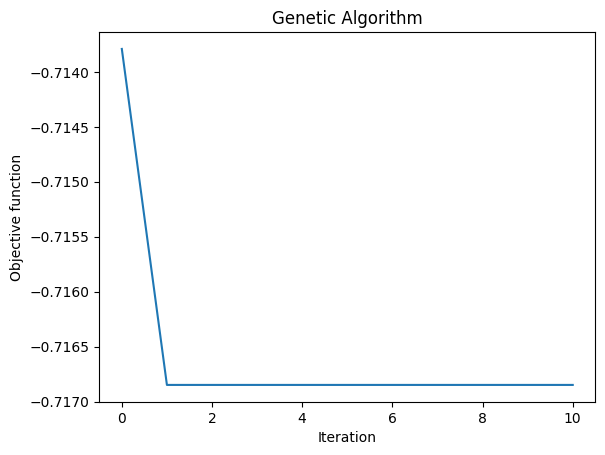

In [29]:
import random

np.random.seed(SEED)
random.seed(SEED)

model.run()

We can see that the best results are obtained in the second generation and then the algorithm converges to a local minimum.

In [30]:
optimized_params = model.output_dict['variable']
print(f"Optimized C: {optimized_params[0]}, Optimized gamma: {optimized_params[1]}")

Optimized C: 542.7418135499327, Optimized gamma: 0.0008786879644302269


Now that we have the best hyperparameters, we can train the SVC with the best hyperparameters and evaluate the model setting the probability to True. 
In this way, we can get the probabilities of the predictions and use them to plot the ROC curve. The results should be better than the ones we get before, since we were not taking into account the probability of the predictions. 
However, the computational time is higher (thus we did not use this approach when looking for the best hyperparameters with the genetic algorithm).

In [ ]:
from sklearn.svm import SVC

svc = SVC(C=optimized_params[0], gamma=optimized_params[1], kernel='rbf', probability=True)
svc.fit(X_train, y_train)
y_pred = svc.predict_proba(X_test)[:, 1]
svc_score_test = roc_auc_score(y_test, y_pred)
print(f'AUC: {svc_score_test:.4f}')

As expected, the results are actually quite good. Now we can plot the confusion matrix and the classification report.

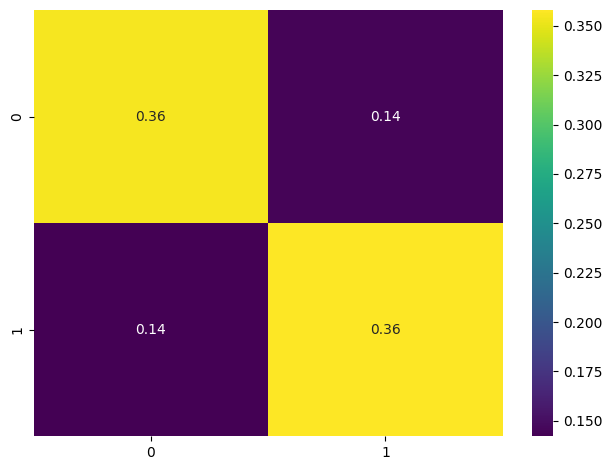

F1-score: 0.7141768292682926


In [52]:
threshold = 0.5
y_pred_binary = (y_pred > threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_binary, labels=[0, 1], normalize='all')
sn.heatmap(cm, annot=True, cmap='viridis')
plt.tight_layout()
plt.show()

print(f'F1-score: {f1_score(y_test, y_pred_binary)}')

# KNN

Another model that we can try is the KNN. Since the only hyperparameter is the number of neighbors, we can use binary search to find the best number of neighbors.

In [43]:
from sklearn.neighbors import KNeighborsClassifier

best_model, best_score = None, 0
cache = {}
l, r = 2, 200

while l <= r:
    mid = (l + r) // 2

    if mid not in cache:
        mid = (l + r) // 2
        mid_model = KNeighborsClassifier(n_neighbors=mid)
        mid_model.fit(X_train, y_train)
        y_pred = mid_model.predict_proba(X_test)[:, 1]
        mid_score = roc_auc_score(y_test, y_pred)
        cache[mid] = mid_score

    if mid-1 not in cache:
        left_model = KNeighborsClassifier(n_neighbors=mid-1)
        left_model.fit(X_train, y_train)
        y_pred = left_model.predict_proba(X_test)[:, 1]
        left_score = roc_auc_score(y_test, y_pred)
        cache[mid-1] = left_score

    if mid_score > best_score:
        best_model, best_score = mid_model, mid_score

    if left_score > mid_score:
        r = mid-1
    else:
        l = mid+1

knn_score_test = best_score
print(f'Best number of neighbors: {best_model.n_neighbors}\nAUC: {best_score:.4f}')

Best number of neighbors: 63
AUC: 0.7533


The KNN model has the best results so far. Let's look at the confusion matrix and the classification report.

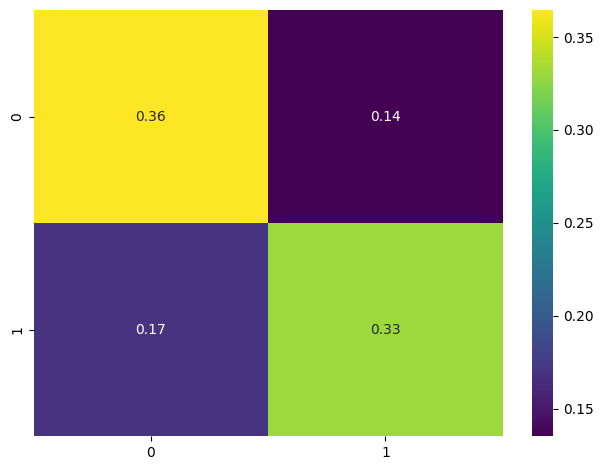

F1-score: 0.6838148001582904


In [54]:
threshold = 0.5
y_pred = best_model.predict_proba(X_test)[:, 1]
y_pred_binary = (y_pred > threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_binary, labels=[0, 1], normalize='all')
sn.heatmap(cm, annot=True, cmap='viridis')
plt.tight_layout()
plt.show()

print(f'F1-score: {f1_score(y_test, y_pred_binary)}')

The confusion matrix is very similar to the ones we get with the other models, but with slighlty worse results than the SVC and the XGBoost.

# Permutation Importance

2025-01-30 17:10:37.888140: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738253438.055347   78341 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738253438.098369   78341 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-30 17:10:38.461767: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


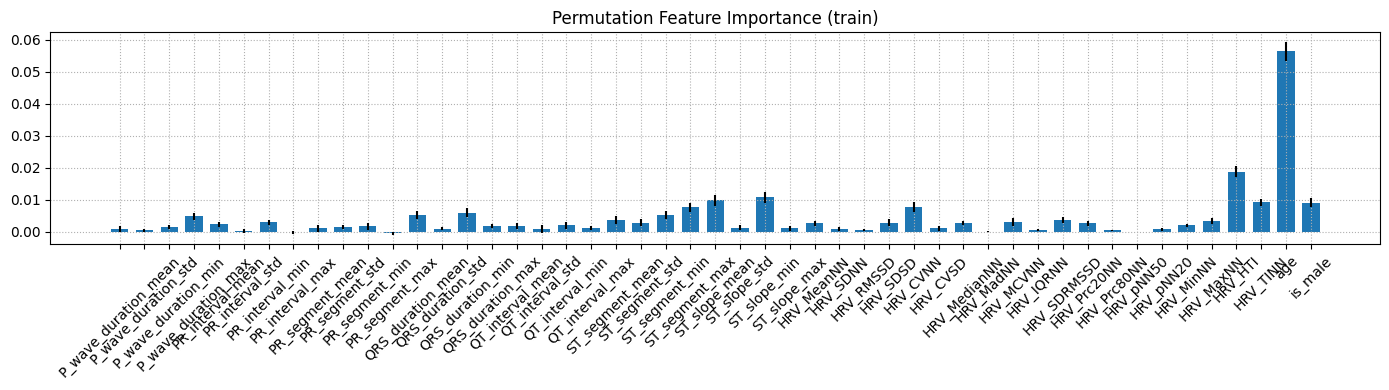

In [96]:
import util

r_train = permutation_importance(xbm, X_train, y_train, n_repeats=30, random_state=SEED)
xbm_p_imp = pd.Series(index=X.columns, data=r_train.importances_mean)
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_train.importances_std, title='Permutation Feature Importance (train)')

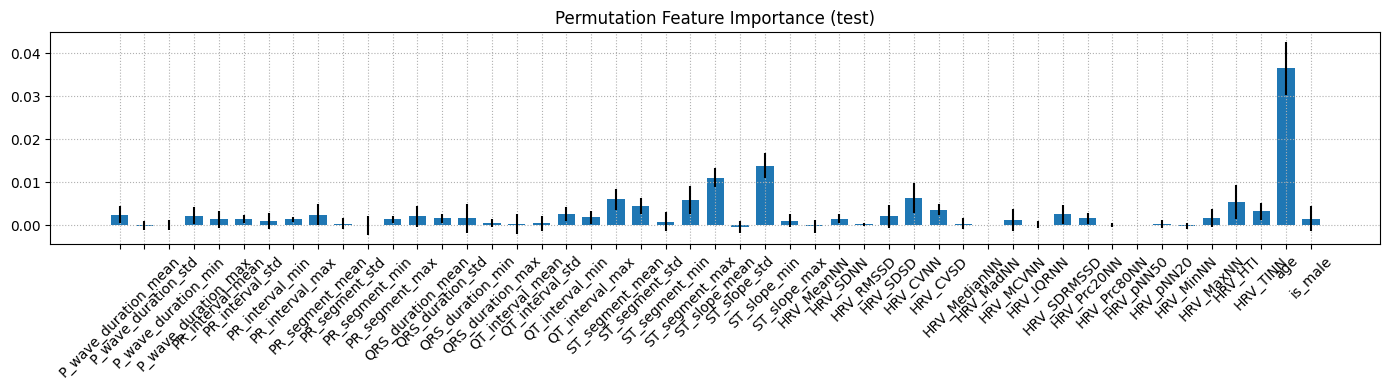

In [97]:
r_test = permutation_importance(xbm, X_test, y_test, n_repeats=30, random_state=SEED)
xbm_p_imp = pd.Series(index=X.columns, data=r_test.importances_mean)
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_test.importances_std, title='Permutation Feature Importance (test)')

# SHAP Values

We can use the SHAP values to explain the predictions of the XGBoost model, as it has very good results.

In [61]:
f = lambda x: xbm.predict_proba(x)[:,1]
explainer = shap.KernelExplainer(f, shap.sample(X_train, 100), link='logit', seed=SEED)
shap_values = explainer(X_test)

100%|██████████| 2617/2617 [57:34<00:00,  1.32s/it] 


Summary plot.

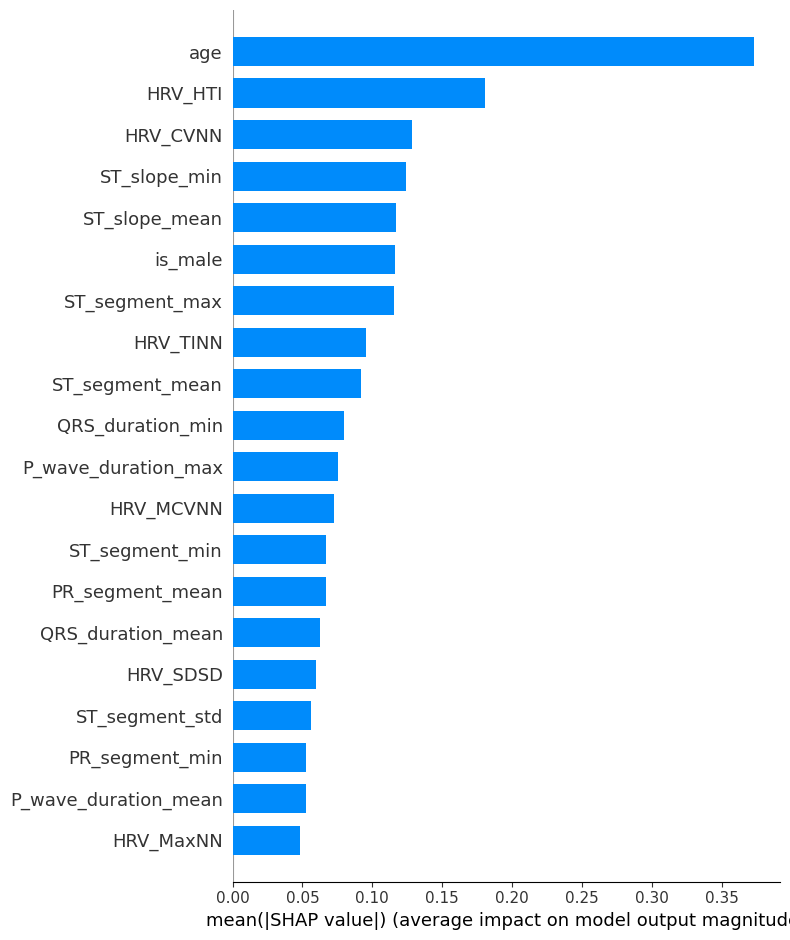

In [70]:
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=20)

Waterfall plot for the SHAP values for a negative sample.

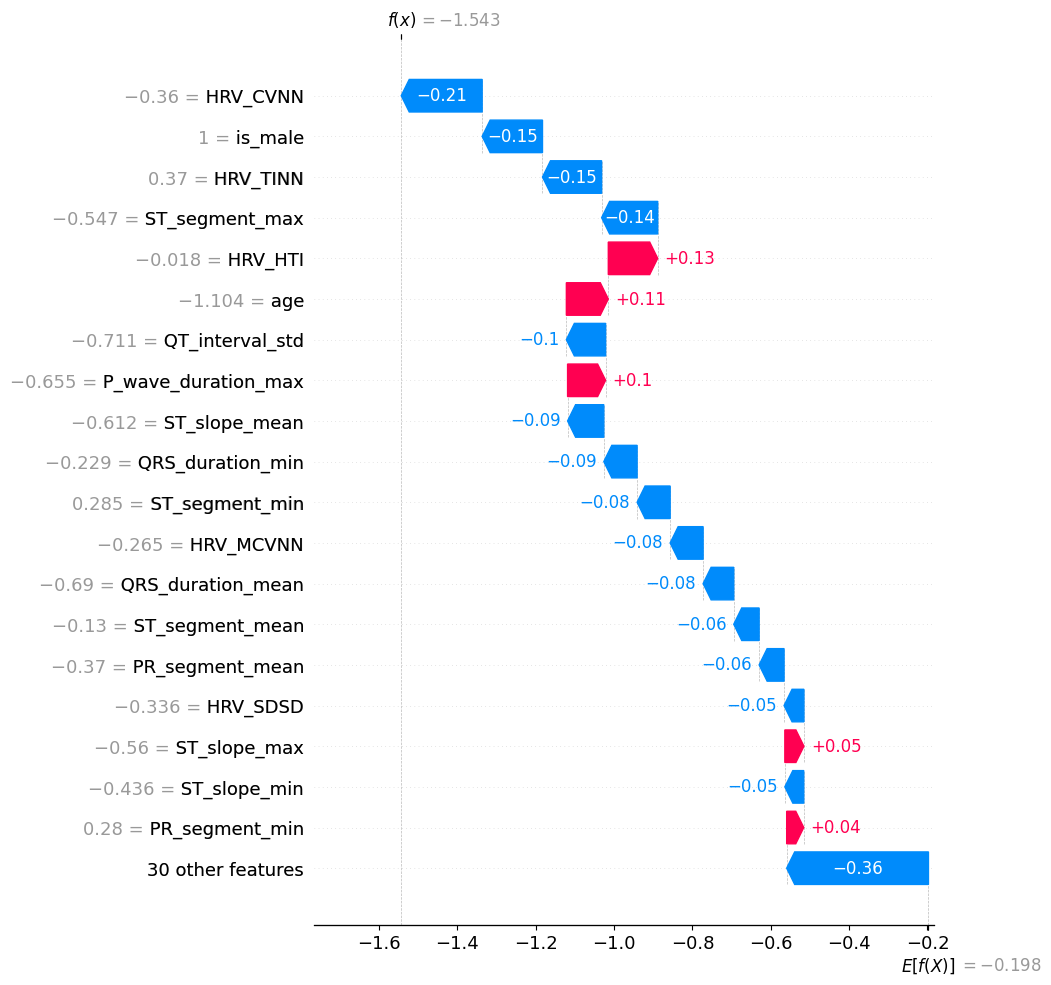

In [71]:
shap.waterfall_plot(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value, data=X_test.iloc[0], feature_names=X.columns.tolist()), max_display=20)

Waterfall plot for the SHAP values for a positive sample.

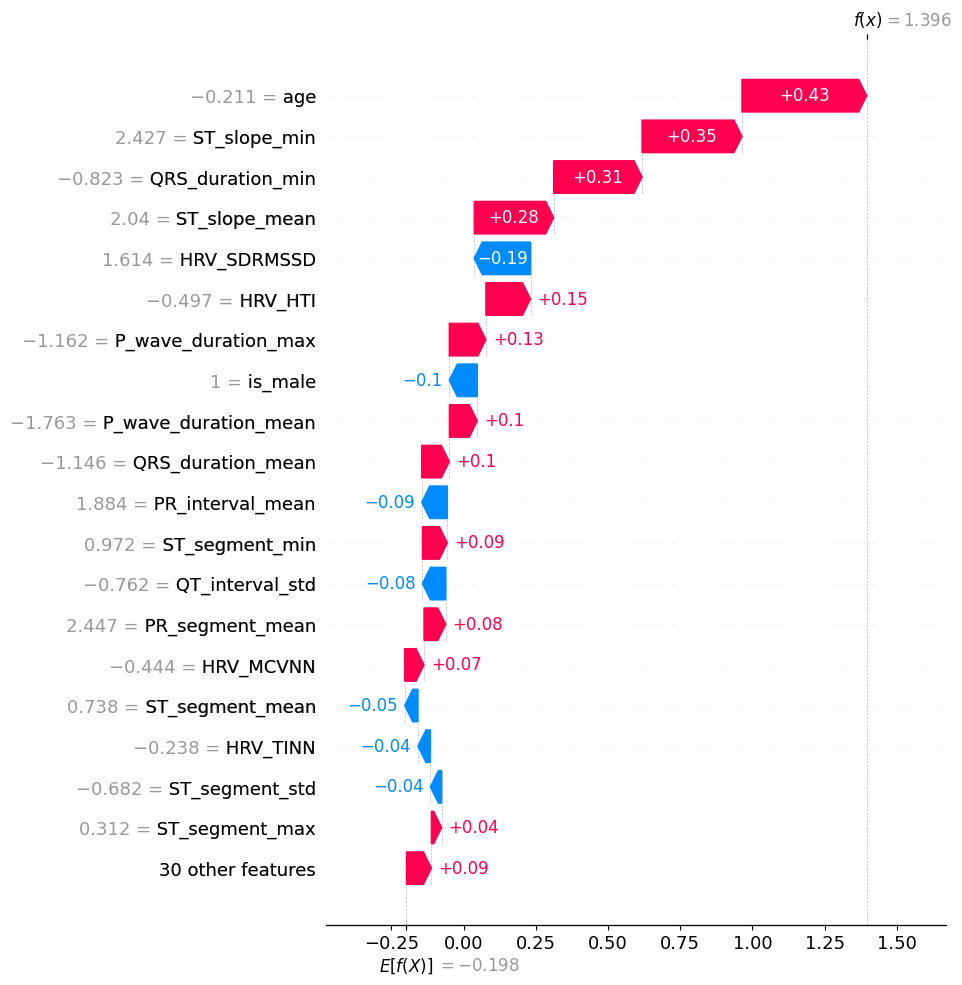

In [72]:
shap.waterfall_plot(shap.Explanation(values=shap_values[1], base_values=explainer.expected_value, data=X_test.iloc[1], feature_names=X.columns.tolist()), max_display=20)

Now we print the beeswarm plot for the SHAP values.

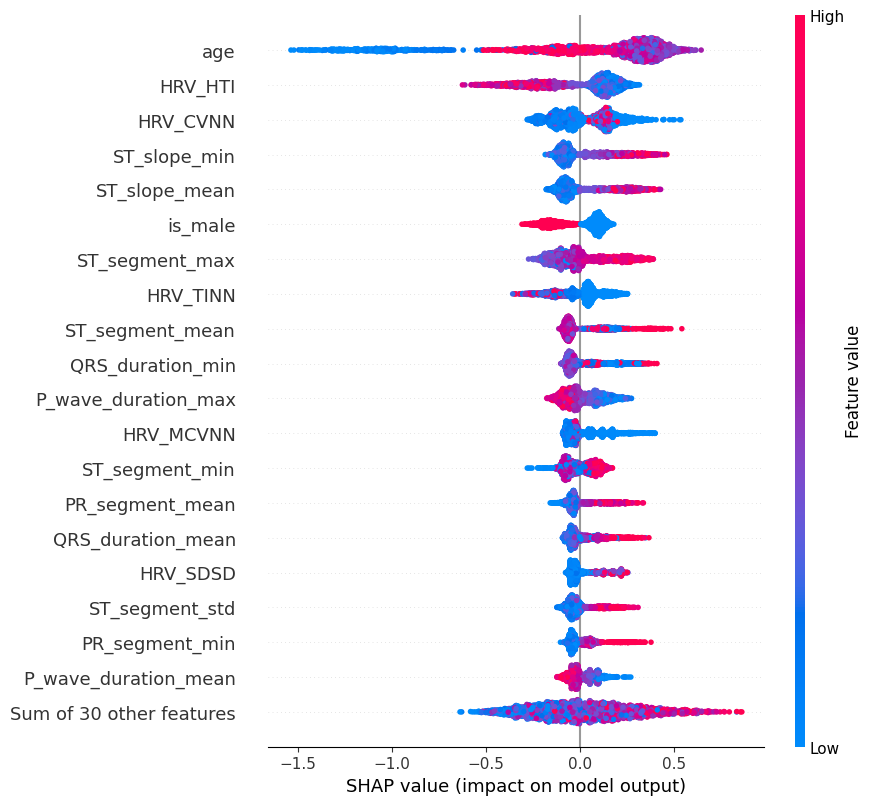

In [69]:
shap.plots.beeswarm(shap_values, max_display=20)

We take the mean of the absolute SHAP values for each feature and select the top 20 features.

In [ ]:
shap_mean = np.abs(shap_values.values).mean(axis=0)
shap_mean = pd.Series(index=X.columns, data=shap_mean)
shap_mean.sort_values(ascending=False, inplace=True)
best_20_shap = shap_mean.head(20)

Now we can run again the XGBoost model with the top 20 features and see the results.

In [ ]:
X_train_fs = X_train[best_20_shap.index]
X_test_fs = X_test[best_20_shap.index]

base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv_fs = GridSearchCV(base_est, param_grid=param_grid)
gscv_fs.fit(X_train_fs, X_test_fs)
xbm_fs, xbm_params_fs = gscv_fs.best_estimator_, gscv_fs.best_params_
y_pred = xbm.predict_proba(X_test)[:, 1]
xbm_score_test_fs = roc_auc_score(y_test, y_pred)

print(f'AUC score for max_depth={xbm_params_fs["max_depth"]}, n_estimators={xbm_params_fs["n_estimators"]}, reg_lambda={xbm_params_fs["reg_lambda"]:.2f}: {xbm_score_test_fs:.4f} (test)')

Now we can plot the confusion matrix and the classification report.

In [ ]:
cm = confusion_matrix(y_test, xbm_fs.predict(X_test_fs), labels=[0, 1], normalize='all')
sn.heatmap(cm, annot=True, cmap='viridis')
plt.tight_layout()
plt.show()

print(f'F1-score: {f1_score(y_test, xbm_fs.predict(X_test_fs))}')

# BorutaPy Feature Selection

In [100]:
bfs = BorutaPy(xbm, n_estimators='auto', max_iter=100, verbose=0, random_state=SEED)
bfs.fit(X=X, y=y)

KeyboardInterrupt: 

In [250]:
print('Confirmed important:', X.columns[bfs.ranking_ == 1].values)
print('Uncomfirmed:', X.columns[bfs.ranking_ == 2].values)
print('Confirmed unimportant:', X.columns[bfs.ranking_ > 2].values)

Confirmed important: ['P_wave_duration_mean' 'P_wave_duration_max' 'PR_interval_std'
 'PR_segment_mean' 'PR_segment_max' 'QRS_duration_min' 'QT_interval_mean'
 'QT_interval_std' 'QT_interval_min' 'QT_interval_max' 'ST_segment_mean'
 'ST_segment_std' 'ST_segment_max' 'ST_slope_mean' 'ST_slope_min'
 'ST_slope_max']
Uncomfirmed: ['P_wave_duration_std' 'ST_segment_min' 'ST_slope_std']
Confirmed unimportant: ['P_wave_duration_min' 'PR_interval_mean' 'PR_interval_min'
 'PR_interval_max' 'PR_segment_std' 'PR_segment_min' 'QRS_duration_mean'
 'QRS_duration_std' 'QRS_duration_max' 'is_male']


---

# Deep Learning

## Why?

Another approach that we can try is to use **Deep Learning** with the aim of improving the results in terms of ROC AUC.

In this context, we can use any kind of deep learning model, such as a simple **feedforward neural network**, a **convolutional neural network**, or a **recurrent neural network**.

However, Fully Connected Neural Networks are not suitable for time series data, as they do not take into account the **temporal dependencies** in the data. Moreover, we do not have only one-dimensional data, but **12 leads** of ECG signals for each record and **demographic information**.

Thus, we can use a Convolutional Neural Network (CNN) to take into account the **spatial dependencies** in the data, as the ECG signals are two-dimensional data. In particular, we can use a **1D CNN** for each lead of the ECG signals and a Fully Connected Neural Network for the demographic information.

We can also use a Recurrent Neural Network (RNN) to take into account the temporal dependencies in the data, as the ECG signals are time series data. This RNN could be put on top of the CNN to take into account both the spatial and temporal dependencies in the data. This approach is the SOTA for a variety of tasks like **Sleep Stage Classification**, **ECG Classification**, etc.

Although these models are more complex than the previous ones, they can provide better results in terms of ROC AUC.

## Explainability?

Deep Learning models are often considered as black boxes, as they are very complex and it is difficult to understand how they make predictions. However, there are some techniques that can help us understand how the model makes predictions, such as SHAP values, LIME, and Grad-CAM. In particular, SHAP values can help us understand the importance of each feature in the model's predictions.

We will try to leverage the Deep Explainer of the SHAP library to explain the predictions of the Deep Learning model.

More sophisticated techniques like LIME and Grad-CAM can also be used to explain the predictions of the Deep Learning model. Grad-CAM can help us understand which parts of the ECG signals are important for the model's predictions as to highlight which leads are more important in the model's predictions. We hypothesize that the lead II is the most important one, as it is the most commonly used lead in ECG analysis but we will see if this is true by using Grad-CAM.

In [ ]:
df = pd.read_csv('data/signals_features.csv')
df = df.fillna(value=0)
scaler = StandardScaler()
scaler.set_output(transform='pandas')
df.iloc[:, 1:-3] = scaler.fit_transform(df.iloc[:, 1:-3])

In [ ]:
def clean_signal(ecg_channel, sampling_rate: int = 400):
    """
    Clean a single ECG channel.
    """
    detrend = nk.signal_detrend(ecg_channel, method='polynomial', order='auto', sampling_rate=sampling_rate)
    cleaned = nk.signal_filter(detrend, sampling_rate=sampling_rate, lowcut=2, highcut=9, method='butterworth')
    return cleaned

The `get_features_and_labels` function takes each of the record inside the data folder and extracts the features and labels from the record. The features are the ECG signals and the demographic information, while the labels are the target variable. To speedup the process, we can use the `joblib` library to parallelize the process and extract the features and labels from each record in parallel (as they are independent from each other).

In [ ]:
def get_features_and_labels(records_id: str, data_folder: Path, clean: bool = False):
    record_path = (data_folder / records_id).absolute().__str__()
    header = load_header(record_path)
    signals, fields = load_signals(record_path)
    if clean:
        signals = np.stack(Parallel(n_jobs=-1)(delayed(clean_signal)(signals[:, channel], sampling_rate=400) for channel in range(signals.shape[1])))
    label = get_label(header)
    age = get_age(header)
    sex = get_sex(header)
    handcrafted = df[df['exam_id'] == int(records_id)].iloc[:, 1:-3].values
    return signals, label, age, sex, handcrafted

The we can create the `ECGDataset` class to load the features and labels so that we can use them to train the deep learning model by leveraging PyTorch datasets and dataloaders.

While creating the `ECGDataset` class, we can also apply some transformations to the features and labels, such as converting them to PyTorch tensors and normalizing the features.

In this context, the age values are normalized in the range [0, 1] while the signals are standardized by subtracting the mean and dividing by the standard deviation.

In some instances, the signals were shorter than the maximum length of 4096, so we padded them with zeros to have the same length for each signal.

At the end, the dataset is split into training and testing sets, and the dataloaders are created to load the data in batches.

In [ ]:
class ECGDataset(Dataset):
    def __init__(self, features, labels, max_len: int=4096):
        signals, ages, sexes, handcrafted = zip(*features)
        ages = np.array(ages)
        self.features = signals
        self.ages = (ages - ages.min()) / (ages.max() - ages.min())
        self.sexes = sexes
        self.labels = labels
        self.handcrafted = handcrafted
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        signals = torch.tensor(self.features[idx], dtype=torch.float32)
        ages = torch.tensor(self.ages[idx], dtype=torch.float32)
        sexes = torch.tensor(self.sexes[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        handcrafted = torch.tensor(self.handcrafted[idx], dtype=torch.float32)

        if signals.size(0) < self.max_len:
            signals = torch.cat([signals, torch.zeros(self.max_len - signals.size(0), signals.size(1))])

        signals = signals.transpose(0, 1)
        label = label.unsqueeze(0)

        signals = (signals - signals.mean()) / signals.std()
        #handcrafted = (handcrafted - handcrafted.min()) / (handcrafted.max() - handcrafted.min() + 1e-8)

        return signals, label, ages, sexes, handcrafted.squeeze(0)

Get the feature and labels for each record in parallel

In [ ]:
data = Parallel(n_jobs=-1)(delayed(get_features_and_labels)(record_id, train_data_folder) for record_id in tqdm(train_records, desc='Loading signals'))

Loading signals: 100%|██████████| 13092/13092 [00:33<00:00, 391.12it/s]


Map the data to the features and labels

In [ ]:
features, labels, ages, sexes, handcrafted = zip(*data)
features = [f for f in features]

In [ ]:
ages = np.array(ages, dtype=np.float32)

In [ ]:
sexes = np.array([1 if sex.lower() == 'male' else 0 for sex in sexes], dtype=np.float32)

Combine the features and labels into a dataset and split it into training and testing sets

In [ ]:
# Combine features with demographic data
X = [(f, age, sex, handcrafted) for f, age, sex, handcrafted in zip(features, ages, sexes, handcrafted)]
y = np.array(labels)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.10, random_state=SEED, stratify=y_train)

print("Train", len(X_train))
print("Val", len(X_val))
print("Test", len(X_test))

Train 9425
Val 1048
Test 2619


In [ ]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_val, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([4709, 4716]))
(array([0, 1]), array([524, 524]))
(array([0, 1]), array([1309, 1310]))


Define the dataloaders to load the data in batches

In [ ]:
BATCH_SIZE = 128

train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)
train_dloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_dloader = DataLoader(test_dataset, shuffle=False)

In [ ]:
train_dloader.dataset[0][4].shape

torch.Size([47])

## Model

The model we are going to use is a 1D Conv SE-ResNet18, which is a convolutional neural network with squeeze-and-excitation blocks and a ResNet18 architecture. The ResNet18 architecture is a convolutional neural network with residual connections that is widely used for image classification tasks. The squeeze-and-excitation blocks are used to model the dependencies between the channels of the input data, which can be useful for ECG signals, as they have multiple leads that are related to each other. In this way, the model can learn the spatial dependencies in the data and improve the performance of the model by focusing on the most important leads.

In order to integrate the demographic information into the model, we can use a Fully Connected Neural Network that takes the demographic information as input and outputs a vector of the same size as the output of the convolutional neural network. This vector can be concatenated with the output of the convolutional neural network and passed through a linear layer to get the final output of the model.

More sophisticated techniques can be used to integrate the demographic information into the model, such as attention mechanisms, by weighting the output of the convolutional neural network based on the demographic information. Alternatives might esplore the Feature-wise Linear Modulation (FiLM) layers by conditioning the convolutional neural network on the demographic information. This intuition comes from the fact that the demographic information can be used to modulate the features extracted by the convolutional neural network, so that the model can learn that specific patterns might also be related to the demographic information. This is particularly useful when the demographic information is related to the target variable, as it can help the model to learn the relationship between the demographic information and the target variable. As we have seen in the EDA, the demographic information is related to the target variable, so it can be useful to integrate it into the model by using a concatenation or a modulation approach.

>**Note**: For our purpose the concatenation approach is enough, but the other approaches can be explored in future work to improve the performance of the model on a greater scale of training data.

In [ ]:
class SELayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SELayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.LeakyReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)



def conv3x1(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv1d(in_planes, out_planes, kernel_size=7, stride=stride,
                     padding=3, bias=False)


def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv1d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x1(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm1d(planes)
        self.relu = nn.LeakyReLU(inplace=True)
        self.conv2 = conv3x1(planes, planes)
        self.bn2 = nn.BatchNorm1d(planes)
        self.se = SELayer(planes)
        self.downsample = downsample
        self.stride = stride
        self.dropout = nn.Dropout(.2)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se(out)
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = conv1x1(inplanes, planes)
        self.bn1 = nn.BatchNorm1d(planes)
        self.conv2 = conv3x1(planes, planes, stride)
        self.bn2 = nn.BatchNorm1d(planes)
        self.conv3 = conv1x1(planes, planes * self.expansion)
        self.bn3 = nn.BatchNorm1d(planes * self.expansion)
        self.se = SELayer(self.expansion * planes)
        self.relu = nn.LeakyReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride
        self.dropout = nn.Dropout(.2)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv3(out)
        out = self.bn3(out)
        out = self.se(out)
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, in_channel=12, out_channel=1, zero_init_residual=False):
        super(ResNet, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv1d(in_channel, 64, kernel_size=15, stride=2, padding=7,
                               bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.LeakyReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        # Demographic data processing
        self.demographic_fc = nn.Sequential(
            nn.Linear(2, 256),  # 2 demographic features: age and sex
            nn.LeakyReLU(),
            nn.Linear(256, 512 * block.expansion),
            nn.LeakyReLU()
        )
        # Final FC
        self.fc = nn.Linear(512 * block.expansion * 2, out_channel)
        #self.sig = nn.Sigmoid()

        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

        """
        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                n = m.kernel_size[0] * m.kernel_size[0] * m.out_channels
                m.weight.data.normal_(0, math.sqrt(2. / n))
            elif isinstance(m, nn.BatchNorm1d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()
        """
    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm1d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)



    def forward(self, ecg_features, demo_features, hand_features):
        x = self.conv1(ecg_features)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = x.view(x.size(0), -1)

        z = self.demographic_fc(demo_features)

        # Concatenate ECG and demographic features
        combined = torch.cat((x, z), dim=1)

        return self.fc(combined)

In [ ]:
import gc

with torch.no_grad():
    torch.cuda.empty_cache()

if 'model' in locals():
    del model
    print("Model deleted!")
gc.collect()

Model deleted!


5345

Parameters of the SE-ResNet18 (the 18 comes from the number of layers in the network, hence the 2, 2, 2, 2 means that there are 2 residual blocks in each of the 4 layers of the network):

In [ ]:
resnet_params = {
    'layers': [2, 2, 2, 2],
    "in_channel":12, 
    "out_channel":1, 
    "zero_init_residual":False
}

The model is trained with the AdamW optimizer and the Binary Cross-Entropy with Logits Loss, which is suitable for binary classification tasks. The learning rate is set to 1e-3 with weight decay of 1e-4 to prevent overfitting.

To handle every possible case of unbalanced data, we gave a score to the positive class based on the sum of the labels of the negative class divided by the sum of all the labels. This score is used to weight the loss function and avoid the model to be biased towards the majority class.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = ResNet(BasicBlock, **resnet_params)
model.to(device)

# Positive class weight
pos_weight = (y==0.).sum()/y.sum()

# Define loss function, optimizer, and scheduler
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

<ipython-input-522-5cbb5f740da5>:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))


In [ ]:
summary(model, input_size=[(BATCH_SIZE, 12, 4096),(BATCH_SIZE, 2),(BATCH_SIZE, 47)])

Layer (type:depth-idx)                        Output Shape              Param #
ResNet                                        [128, 1]                  --
├─Conv1d: 1-1                                 [128, 64, 2048]           11,520
├─BatchNorm1d: 1-2                            [128, 64, 2048]           128
├─LeakyReLU: 1-3                              [128, 64, 2048]           --
├─MaxPool1d: 1-4                              [128, 64, 1024]           --
├─Sequential: 1-5                             [128, 64, 1024]           --
│    └─BasicBlock: 2-1                        [128, 64, 1024]           --
│    │    └─Conv1d: 3-1                       [128, 64, 1024]           28,672
│    │    └─BatchNorm1d: 3-2                  [128, 64, 1024]           128
│    │    └─LeakyReLU: 3-3                    [128, 64, 1024]           --
│    │    └─Dropout: 3-4                      [128, 64, 1024]           --
│    │    └─Conv1d: 3-5                       [128, 64, 1024]           28,672
│    │

The model is then trained for 30 epochs with early stopping based on the validation loss to prevent overfitting. The model is saved when the validation loss is minimized. After 10 epochs without improvement, the training is stopped.

The learning rate follows a Cosine Annealing Schedule, which decreases the learning rate from the initial value to a minimum value in a range of epochs. This can help the model to converge faster and avoid local minima by reducing the learning rate as the training progresses.

On each epoch, the training data is shuffled and the model is set to training mode to update the weights based on the loss. The model is then set to evaluation mode to evaluate the performance on the validation data. The performance is evaluated in terms of ROC AUC, which is a suitable metric for binary classification tasks.

The model is then evaluated on the testing data to get the final performance of the model. The performance is again evaluated in terms of ROC AUC while also plotting the confusion matrix for a better understanding of the results.

In [ ]:
epochs = 30
best_val_loss = float('inf')
patience_counter = 0
patience = 10

# Initialize Warmup Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    eta_min=1e-5,
    T_max=74*15,
)

for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    n_elements = 0
    for X, y, age, sex, handcrafted in tqdm(train_dloader, desc=f"Epoch {epoch+1}/{epochs}"):
        X, y = X.to(device), y.to(device)
        age, sex = age.to(device), sex.to(device)
        handcrafted = handcrafted.to(device)
        # Combine age and sex into a single demographic tensor
        demographic = torch.stack((age, sex), dim=1)
        
        optimizer.zero_grad()
        outputs = model(X, demographic, handcrafted)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item()
        n_elements += len(X)
    
    train_loss /= n_elements
    
    model.eval()
    val_loss = 0.0
    preds = []
    probabilities = []
    labels = []
    with torch.no_grad():
        for X, y, age, sex, handcrafted in val_dloader:
            X, y = X.to(device), y.to(device)
            age, sex = age.to(device), sex.to(device)
            demographic = torch.stack((age, sex), dim=1)
            handcrafted = handcrafted.to(device)
            outputs = model(X, demographic, handcrafted)
            loss = criterion(outputs, y)
            val_loss += loss.item()
            probs = torch.sigmoid(outputs)  # Convert logits to probabilities
            y_pred = (probs >= 0.5).long()  # Convert probabilities to {0,1}
            probabilities.extend(probs.cpu().numpy())
            preds.extend(y_pred.cpu().numpy())  # Convert to NumPy array
            labels.extend(y.cpu().numpy())
    
    val_loss /= len(val_dloader)
    
    predictions = np.array(preds)
    probabilities = np.array(probabilities)
    labels = np.array(labels)
    
    print(f"Epoch {epoch+1}/{epochs}\tTrain Loss: {train_loss:.6f}\tVal Loss: {val_loss:.6f}\tL.rate: {optimizer.param_groups[0]['lr']:.6f}\tVal F1: {f1_score(labels, predictions):.4f}\tVal ROC-AUC: {roc_auc_score(labels, probabilities):.4f}")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

Epoch 1/30: 100%|██████████| 74/74 [00:16<00:00,  4.62it/s]


Epoch 1/30	Train Loss: 0.004195	Val Loss: 0.508769	L.rate: 0.000989	Val F1: 0.7804	Val ROC-AUC: 0.8425


Epoch 2/30: 100%|██████████| 74/74 [00:15<00:00,  4.63it/s]


Epoch 2/30	Train Loss: 0.003943	Val Loss: 0.489445	L.rate: 0.000957	Val F1: 0.7825	Val ROC-AUC: 0.8494


Epoch 3/30: 100%|██████████| 74/74 [00:15<00:00,  4.67it/s]


...

Epoch 13/30	Train Loss: 0.002843	Val Loss: 0.538564	L.rate: 0.000053	Val F1: 0.7294	Val ROC-AUC: 0.8277


Epoch 14/30: 100%|██████████| 74/74 [00:15<00:00,  4.64it/s]


Epoch 14/30	Train Loss: 0.002693	Val Loss: 0.549591	L.rate: 0.000021	Val F1: 0.7468	Val ROC-AUC: 0.8275


Epoch 15/30: 100%|██████████| 74/74 [00:15<00:00,  4.65it/s]


Epoch 15/30	Train Loss: 0.002562	Val Loss: 0.561169	L.rate: 0.000010	Val F1: 0.7461	Val ROC-AUC: 0.8221
Early stopping triggered.


In [ ]:
model = ResNet(BasicBlock, **resnet_params)
model.to(device)
model.load_state_dict(torch.load("best_model.pth", weights_only=True))

<All keys matched successfully>

In [ ]:
model.eval()

# Initialize a list to store predictions
predictions = []
probabilities = []

# Disable gradient calculation for inference
with torch.no_grad():
    for X, _, age, sex, handcrafted in tqdm(test_dloader, desc="Predicting"):
        X = X.to(device)
        age, sex = age.to(device), sex.to(device)
        demographic = torch.stack((age, sex), dim=1)
        handcrafted = handcrafted.to(device)
        outputs = model(X, demographic, handcrafted)  # Raw logits
        probs = torch.sigmoid(outputs)  # Convert logits to probabilities
        y_pred = (probs >= 0.50).long()  # Convert probabilities to {0,1}
        probabilities.extend(probs.cpu().numpy())  # Convert to NumPy array
        predictions.extend(y_pred.cpu().numpy())  # Convert to NumPy array

# Convert predictions to a NumPy array
predictions = np.array(predictions)
probabilities = np.array(probabilities)

Predicting: 100%|██████████| 2619/2619 [00:21<00:00, 122.14it/s]


In [ ]:
model_graph = draw_graph(model, input_size=[(BATCH_SIZE, 12, 4096),(BATCH_SIZE, 2),(BATCH_SIZE, 47)], device='meta', save_graph=True, filename='se-resnet18')
model_graph.visual_graph

In [ ]:
print("Accuracy", accuracy_score(y_test, predictions))
print("F1 score", f1_score(y_test, predictions, average='macro'))
print("F-beta score", fbeta_score(y_test, predictions, beta=0.5))
print("ROC-AUC score", roc_auc_score(y_test, probabilities))

Accuracy 0.7617411225658648
F1 score 0.7617119061227823
F-beta score 0.7595316721705194
ROC-AUC score 0.8506382705754056


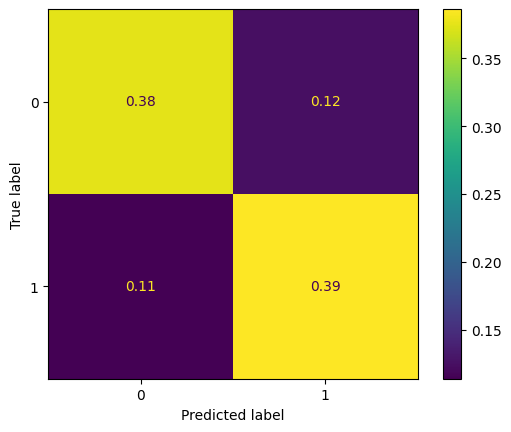

In [ ]:
cm = confusion_matrix(y_test, predictions, normalize='all')
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

### Optuna

For the hyperparameter optimization, we can use Optuna, which is a hyperparameter optimization framework that can be used to find the best hyperparameters for the model. In this context, we can use Optuna to find the best learning rate, weight decay, and batch size for the model. The learning rate is the most important hyperparameter, as it controls how fast the model learns, while the weight decay is used to prevent overfitting by penalizing large weights. The batch size is the number of samples that are used to update the weights of the model, and it can affect the performance of the model by changing the noise in the gradients.

After experimenting with Optuna, we realized that the default values for the hyperparameters are already quite good, so we decided to keep them as they are. However, we can still use Optuna to find the best hyperparameters for the model, as it can help to improve the performance of the model by finding the best set of hyperparameters.

However, better approaches might explore the Neural Architecture Search (NAS) to find the best architecture for the model. This task is computationally expensive and requires a lot of resources as the number of possible architectures is huge.

In [ ]:
def objective(trial):
    # Suggest hyperparameters
    batch_size = trial.suggest_int('batch_size', 64, 256)
    lr = trial.suggest_float('lr', 1e-4, 1e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)

    # DataLoader
    train_dloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_dloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    test_dloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Model
    resnet_params = {
        'layers': [2, 2, 2, 2],
        "in_channel":12, 
        "out_channel":1, 
        "zero_init_residual":True
    }
    model = ResNet(Bottleneck, **resnet_params)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    # Define loss function, optimizer, and scheduler
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

    # Training loop
    epochs = 20
    best_val_loss = float('inf')
    patience_counter = 0
    patience = 7
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        n_elements = 0
        for X, y, age, sex in tqdm(train_dloader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)
            age, sex = age.to(device), sex.to(device)
            # Combine age and sex into a single demographic tensor
            demographic = torch.stack((age, sex), dim=1)
            
            optimizer.zero_grad()
            outputs = model(X, demographic)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            n_elements += len(X)
        
        train_loss /= n_elements
        
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X, y, age, sex in val_dloader:
                X, y = X.to(device), y.to(device)
                age, sex = age.to(device), sex.to(device)
                demographic = torch.stack((age, sex), dim=1)
                outputs = model(X, demographic)
                loss = criterion(outputs, y)
                val_loss += loss.item()
        
        val_loss /= len(val_dloader)
        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{epochs}\tTrain Loss: {train_loss:.4f}\tVal Loss: {val_loss:.4f}\tL.rate: {optimizer.param_groups[0]['lr']:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    # Load back the best model found
    model = ResNet(Bottleneck, **resnet_params)
    model.to(device)
    model.load_state_dict(torch.load("best_model.pth", weights_only=True))

    # Test the model
    model.eval()
    
    # Initialize a list to store predictions
    predictions = []
    
    # Disable gradient calculation for inference
    with torch.no_grad():
        for X, _, age, sex in tqdm(test_dloader, desc="Predicting"):
            X = X.to(device)
            age, sex = age.to(device), sex.to(device)
            demographic = torch.stack((age, sex), dim=1)
            outputs = model(X, demographic)  # Raw logits
            probs = torch.sigmoid(outputs)  # Convert logits to probabilities
            y_pred = (probs >= 0.5).long()  # Convert probabilities to {0,1}
            predictions.extend(y_pred.cpu().numpy())  # Convert to NumPy array
    
    # Convert predictions to a NumPy array
    predictions = np.array(predictions)

    # Metrics
    rocauc = roc_auc_score(y_test, predictions)

    return rocauc

In [ ]:
# Create an Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

In [ ]:
# Display the best hyperparameters and ROC AUC score
print("Best hyperparameters:", study.best_params)
print("Best ROC-AUC:", study.best_value)

---

# Transformers